## 당뇨병 수치 맞추기

### 데이터 준비

In [27]:
from sklearn.datasets import load_diabetes
import pandas as pd

data = load_diabetes()
df_X = pd.DataFrame(data.data, columns=data.feature_names)
df_y = pd.Series(data.target, name="target")

In [28]:
print(df_X.columns)
print(df_X.head())
print(df_y.head())

Index(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6'], dtype='object')
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  
0 -0.002592  0.019907 -0.017646  
1 -0.039493 -0.068332 -0.092204  
2 -0.002592  0.002861 -0.025930  
3  0.034309  0.022688 -0.009362  
4 -0.002592 -0.031988 -0.046641  
0    151.0
1     75.0
2    141.0
3    206.0
4    135.0
Name: target, dtype: float64


In [29]:
# 모델 데이터 X, y 준비하기
import numpy as np

X = np.array(df_X)
y = np.array(df_y)

print(type(X), X.dtype)
print(type(y), y.dtype)

<class 'numpy.ndarray'> float64
<class 'numpy.ndarray'> float64


### 데이터셋 분리

In [30]:
from sklearn.model_selection import train_test_split

X_train,  X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(353, 10) (353,)
(89, 10) (89,)


### 모델 준비하기

In [31]:
W = np.random.rand(X_train.shape[1])
b = np.random.rand()
print(len(W))

10


In [32]:
def model(X, W, b):
    predictions = 0
    for i in range(len(W)):
        predictions += X[:, i] * W[i]
    predictions += b
    return predictions

### loss function

In [33]:
def MSE(a, b):
    mse = ((a - b)**2).mean()
    return mse

In [34]:
def loss(X, W, b, y):
    predictions = model(X, W, b)
    L = MSE(predictions, y)
    return L

### gradient function

In [35]:
def gradient(X, W, b, y):
    N = len(y)
    y_pred = model(X, W, b)
    dW = 1/N * 2 * X.T.dot(y_pred - y)
    db = 2 * (y_pred - y).mean()
    return dW, db

### 모델 학습하기

In [36]:
LEARNING_RATE = 0.1

In [37]:
%%timeit -n 1 -r 1
global W, b

losses = []

for i in range(1, 2001):
    dW, db = gradient(X_train, W, b, y_train)
    W -= LEARNING_RATE * dW
    b -= LEARNING_RATE * db
    L = loss(X_train, W, b, y_train)
    losses.append(L)
    if i % 100 == 0:
        print('Iteration %d : Loss %0.4f' % (i, L))

Iteration 100 : Loss 5379.1350
Iteration 200 : Loss 4876.5228
Iteration 300 : Loss 4502.8333
Iteration 400 : Loss 4221.3078
Iteration 500 : Loss 4006.0868
Iteration 600 : Loss 3838.9340
Iteration 700 : Loss 3706.9497
Iteration 800 : Loss 3600.9739
Iteration 900 : Loss 3514.4710
Iteration 1000 : Loss 3442.7508
Iteration 1100 : Loss 3382.4235
Iteration 1200 : Loss 3331.0177
Iteration 1300 : Loss 3286.7142
Iteration 1400 : Loss 3248.1574
Iteration 1500 : Loss 3214.3246
Iteration 1600 : Loss 3184.4324
Iteration 1700 : Loss 3157.8719
Iteration 1800 : Loss 3134.1619
Iteration 1900 : Loss 3112.9158
Iteration 2000 : Loss 3093.8183
253 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


### test

In [38]:
prediction = model(X_test, W, b)
mse = loss(X_test, W, b, y_test)
mse

np.float64(2907.1810352102334)

### 정답 데이터와 예측 데이터 시각화

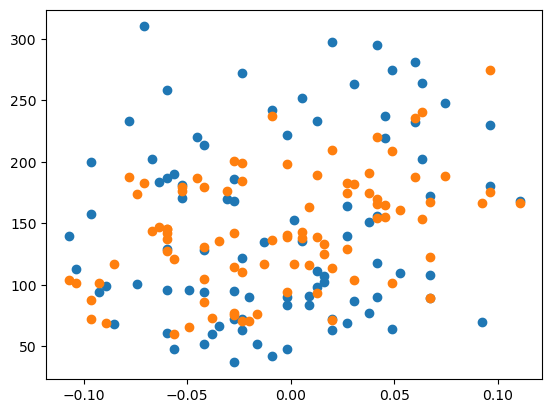

In [39]:
import matplotlib.pyplot as plt

plt.scatter(X_test[:, 0], y_test)
plt.scatter(X_test[:, 0], prediction)
plt.show()